# Реализация ансамблевых методов с оценкой неопределенности

Что сделано:

- обучены 5 разных базовых моделей;
- для регрессии применен `StratifiedKFold(K=5)` через бинирование целевой переменной;
- построен стекинг на out-of-fold предсказаниях базовых моделей;
- рассчитаны эпистемическая, алеаторная и суммарная неопределенности;
- построены таблицы и графики качества и связи неопределенности с фактической ошибкой.

## 1. Импорт библиотек и настройки

In [ ]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "target"
DATA_PATH = Path("train.csv")

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.max_columns", 100)

## 2. Загрузка данных и первичный анализ

Датасет содержит 36 671 объект и 15 столбцов. Целевая переменная `target`
            принимает значения от 0 до 365, что похоже на ограниченную по календарным дням
            величину. Распределение цели несимметричное: медиана равна 45, среднее равно
            112.77, а 25-й процентиль равен 0. Это означает, что в данных много объектов
            с нулевым значением `target`, но при этом есть большая группа объектов с
            высокими значениями.

Самые важные пропуски находятся в `last_dt` и `avg_reviews`: по 7 502 пропуска,
            то есть 20.46% данных. Эти пропуски, вероятно, связаны с отсутствием отзывов,
            поэтому их нельзя просто считать случайными. В дальнейшем для них добавлены
            отдельные индикаторы пропуска, чтобы модель могла использовать сам факт отсутствия
            отзывов как сигнал.

Гистограмма `target` показывает концентрацию около нуля и широкий разброс значений.
            Boxplot подтверждает, что распределение сильно растянуто и не похоже на нормальное.
            Поэтому для задачи ожидаемо лучше подходят нелинейные модели и ансамбли деревьев,
            а простая линейная модель нужна скорее как базовый ориентир.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head())

Размер датасета: 36671 строк, 15 столбцов


,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155


In [ ]:
info_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_share": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(),
})
display(info_table)
display(df[TARGET].describe().to_frame("target"))

,dtype,missing,missing_share,nunique
name,str,9,0.02,36076
_id,int64,0,0.00,29141
host_name,str,18,0.05,9629
location_cluster,str,0,0.00,5
location,str,0,0.00,220
lat,float64,0,0.00,16968
lon,float64,0,0.00,13295
type_house,str,0,0.00,3
sum,int64,0,0.00,625
min_days,int64,0,0.00,96


,target
count,36671.000000
mean,112.766628
std,131.583284
min,0.000000
25%,0.000000
50%,45.000000
75%,227.000000
max,365.000000


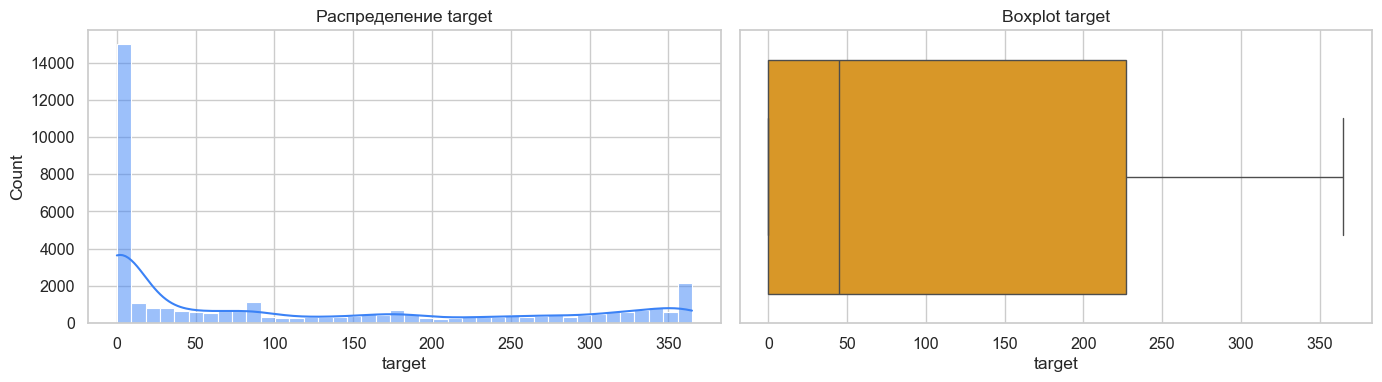

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="#3b82f6")
axes[0].set_title("Распределение target")
axes[0].set_xlabel("target")

sns.boxplot(x=df[TARGET], ax=axes[1], color="#f59e0b")
axes[1].set_title("Boxplot target")
axes[1].set_xlabel("target")

plt.tight_layout()
plt.show()

## 3. Feature engineering и разбиение на train / holdout


Из `train.csv` была выделена внутренняя тестовая выборка `holdout`.
            Получилось 29 336 строк для обучения и OOF-стекинга и 7 335 строк для итоговой
            проверки. Это позволяет считать MSE и фактическую ошибку, потому что для holdout
            известен настоящий `target`.

Для регрессии использована стратификация через бинирование `target`.
            Это нужно потому, что обычный `StratifiedKFold` работает с классами, а не с
            непрерывной целевой переменной. Бинирование сохраняет похожее распределение
            целевой переменной в фолдах и в holdout, особенно с учетом большого числа нулей.

 В feature engineering текстовые поля `name` и `host_name` не использовались как
            высококардинальные категории. Вместо этого из них извлечены простые числовые
            признаки длины и числа слов. Дата последнего отзыва преобразована в возраст
            последнего отзыва, год, месяц и индикатор пропуска. Также добавлены признаки
            `has_reviews`, `reviews_per_host_listing` и `sum_per_min_day`, которые отражают
            смысл предметной области: активность отзывов, масштаб хоста и соотношение цены
            с минимальным сроком аренды.

In [ ]:
def make_target_bins(y, n_bins=10):
    """Стратификационные бины для регрессии.

    Ранжирование помогает избежать проблемы одинаковых значений target
    при квантильном разбиении, особенно из-за большого количества нулей.
    """
    ranked = pd.Series(y).rank(method="first")
    return pd.qcut(ranked, q=n_bins, labels=False, duplicates="drop").astype(int)


train_df, holdout_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=make_target_bins(df[TARGET], n_bins=10),
)

train_df = train_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

X_train_raw = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(float).to_numpy()
X_holdout_raw = holdout_df.drop(columns=[TARGET])
y_holdout = holdout_df[TARGET].astype(float).to_numpy()

reference_date = pd.to_datetime(X_train_raw["last_dt"], errors="coerce").max() + pd.Timedelta(days=1)

print(f"Train для OOF-стекинга: {X_train_raw.shape}")
print(f"Holdout/test: {X_holdout_raw.shape}")
print(f"Reference date для last_dt: {reference_date.date()}")

Train для OOF-стекинга: (29336, 14)
Holdout/test: (7335, 14)
Reference date для last_dt: 2019-07-09


In [ ]:
def add_features(X):
    X = X.copy()

    last_dt = pd.to_datetime(X["last_dt"], errors="coerce")
    name = X["name"].fillna("")
    host_name = X["host_name"].fillna("")

    X["name_len"] = name.str.len()
    X["name_words"] = name.str.split().str.len().fillna(0)
    X["host_name_len"] = host_name.str.len()
    X["last_dt_missing"] = last_dt.isna().astype(int)
    X["last_review_age"] = (reference_date - last_dt).dt.days
    X["last_review_year"] = last_dt.dt.year
    X["last_review_month"] = last_dt.dt.month
    X["avg_reviews_missing"] = X["avg_reviews"].isna().astype(int)
    X["has_reviews"] = (X["amt_reviews"] > 0).astype(int)
    X["reviews_per_host_listing"] = X["amt_reviews"] / (X["total_host"] + 1)
    X["sum_per_min_day"] = X["sum"] / (X["min_days"] + 1)
    X["lat_lon_product"] = X["lat"] * X["lon"]

    return X.drop(columns=["name", "host_name", "last_dt", "_id"])


X_train = add_features(X_train_raw)
X_holdout = add_features(X_holdout_raw)

categorical_features = ["location_cluster", "location", "type_house"]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Категориальные признаки:", categorical_features)
print("Числовые признаки:", numeric_features)
display(X_train.head())

Категориальные признаки: ['location_cluster', 'location', 'type_house']
Числовые признаки: ['lat', 'lon', 'sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'name_len', 'name_words', 'host_name_len', 'last_dt_missing', 'last_review_age', 'last_review_year', 'last_review_month', 'avg_reviews_missing', 'has_reviews', 'reviews_per_host_listing', 'sum_per_min_day', 'lat_lon_product']


,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,name_len,name_words,host_name_len,last_dt_missing,last_review_age,last_review_year,last_review_month,avg_reviews_missing,has_reviews,reviews_per_host_listing,sum_per_min_day,lat_lon_product
0,Brooklyn,Greenpoint,40.73282,-73.95640,Entire home/apt,109,30,9,0.26,1,30,6,7,0,830.0,2017.0,3.0,0,1,4.500000,3.516129,-3012.452729
1,Manhattan,Midtown,40.76639,-73.98163,Entire home/apt,225,30,0,NaN,12,43,8,6,1,NaN,NaN,NaN,1,0,0.000000,7.258065,-3015.963981
2,Queens,Woodhaven,40.69454,-73.85041,Private room,45,5,34,0.85,6,29,6,4,0,29.0,2019.0,6.0,0,1,4.857143,7.500000,-3005.308464
3,Brooklyn,Crown Heights,40.67130,-73.95603,Entire home/apt,120,2,0,NaN,1,31,6,5,1,NaN,NaN,NaN,1,0,0.000000,40.000000,-3007.887883
4,Brooklyn,Williamsburg,40.70741,-73.94233,Entire home/apt,120,2,0,NaN,1,48,8,5,1,NaN,NaN,NaN,1,0,0.000000,40.000000,-3010.000744


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 4. Базовые модели и Stratified K-Fold

### Подробные выводы по базовым моделям

Были обучены пять разных моделей: `Ridge`, `RandomForestRegressor`,
            `ExtraTreesRegressor`, `GradientBoostingRegressor` и `HistGradientBoostingRegressor`.
            Такой набор дает разнообразный ансамбль: линейная модель задает простой baseline,
            случайные леса и ExtraTrees используют bagging-подход, а градиентные бустинги
            последовательно исправляют ошибки предыдущих деревьев.

По holdout MSE лучшей одиночной моделью стала `HistGradientBoosting`:
            10 270.408. Очень близко к ней оказался `RandomForest`: 10 324.509.
            `ExtraTrees` показал 10 595.966, `GradientBoosting` — 10 978.801,
            а `Ridge` заметно хуже — 13 456.867.

Такой порядок моделей показывает, что в данных есть выраженные нелинейные
            зависимости и взаимодействия признаков. Линейной модели недостаточно, а ансамбли
            деревьев лучше описывают структуру данных. При этом OOF MSE и holdout MSE у
            сильных моделей близки, значит оценка качества достаточно стабильна и не выглядит
            как явное переобучение.

In [ ]:
base_models = {
    "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=120,
        max_depth=14,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=140,
        max_depth=16,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=220,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    ),
}


def build_pipeline(model):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model),
    ])


cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_bins = make_target_bins(y_train, n_bins=10)

In [ ]:
oof_predictions = np.zeros((len(X_train), len(base_models)))
holdout_model_predictions = np.zeros((len(X_holdout), len(base_models)))
fold_metrics = []
fitted_fold_models = {}

for model_idx, (model_name, model) in enumerate(base_models.items()):
    print(f"\nОбучение модели: {model_name}")
    fold_holdout_preds = []
    fitted_fold_models[model_name] = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, cv_bins), start=1):
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train[tr_idx]
        y_val = y_train[val_idx]

        pipe = build_pipeline(clone(model))
        pipe.fit(X_tr, y_tr)

        val_pred = np.clip(pipe.predict(X_val), 0, 365)
        holdout_pred = np.clip(pipe.predict(X_holdout), 0, 365)

        oof_predictions[val_idx, model_idx] = val_pred
        fold_holdout_preds.append(holdout_pred)
        fitted_fold_models[model_name].append(pipe)

        fold_mse = mean_squared_error(y_val, val_pred)
        fold_metrics.append({
            "model": model_name,
            "fold": fold,
            "fold_mse": fold_mse,
        })
        print(f"  Fold {fold}: MSE = {fold_mse:.3f}")

    holdout_model_predictions[:, model_idx] = np.mean(fold_holdout_preds, axis=0)

fold_metrics_df = pd.DataFrame(fold_metrics)
display(fold_metrics_df)


Обучение модели: Ridge


  Fold 1: MSE = 13360.819


  Fold 2: MSE = 13589.414


  Fold 3: MSE = 13478.871


  Fold 4: MSE = 13536.832


...

  Fold 2: MSE = 10400.097


  Fold 3: MSE = 9951.958


  Fold 4: MSE = 10332.582


  Fold 5: MSE = 10529.232


,model,fold,fold_mse
0,Ridge,1,13360.818989
1,Ridge,2,13589.413879
2,Ridge,3,13478.871421
3,Ridge,4,13536.832400
4,Ridge,5,13585.371588
5,RandomForest,1,10428.285633
6,RandomForest,2,10425.980307
7,RandomForest,3,10107.183077
8,RandomForest,4,10461.636139
9,RandomForest,5,10478.843890


In [ ]:
base_summary = []
for idx, model_name in enumerate(base_models):
    oof_mse = mean_squared_error(y_train, oof_predictions[:, idx])
    holdout_mse = mean_squared_error(y_holdout, holdout_model_predictions[:, idx])
    base_summary.append({
        "model": model_name,
        "oof_mse": oof_mse,
        "holdout_mse": holdout_mse,
        "fold_mse_mean": fold_metrics_df.loc[fold_metrics_df["model"] == model_name, "fold_mse"].mean(),
        "fold_mse_std": fold_metrics_df.loc[fold_metrics_df["model"] == model_name, "fold_mse"].std(),
    })

base_summary_df = pd.DataFrame(base_summary).sort_values("holdout_mse")
display(base_summary_df)

,model,oof_mse,holdout_mse,fold_mse_mean,fold_mse_std
4,HistGradientBoosting,10307.643846,10270.407776,10307.643276,215.094406
1,RandomForest,10380.387442,10324.508654,10380.385809,154.360450
2,ExtraTrees,10647.038582,10595.966332,10647.037965,162.618833
3,GradientBoosting,10928.654355,10978.801362,10928.654505,178.632277
0,Ridge,13510.256561,13456.866586,13510.261655,94.777421


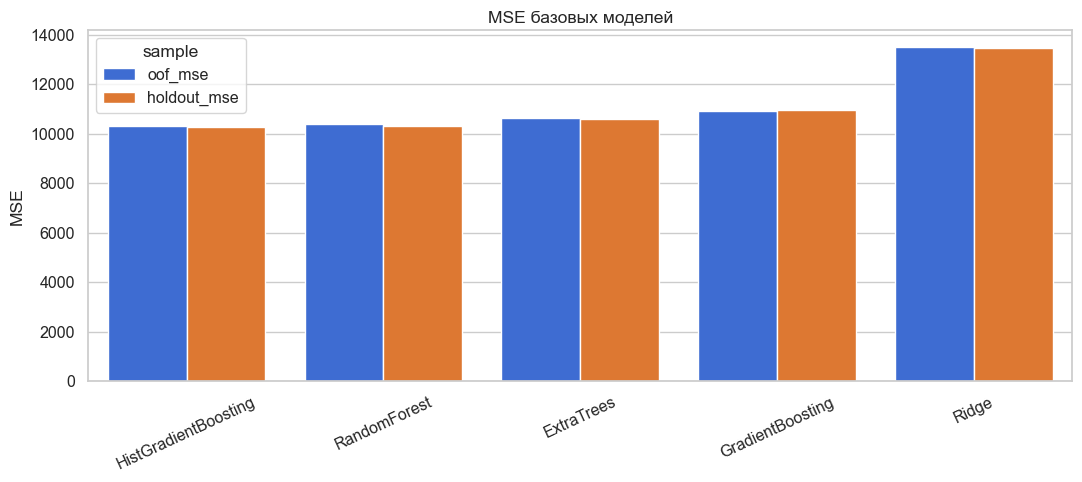

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = base_summary_df.melt(
    id_vars="model",
    value_vars=["oof_mse", "holdout_mse"],
    var_name="sample",
    value_name="mse",
)
sns.barplot(data=plot_df, x="model", y="mse", hue="sample", ax=ax, palette=["#2563eb", "#f97316"])
ax.set_title("MSE базовых моделей")
ax.set_xlabel("")
ax.set_ylabel("MSE")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 5. Стекинг

### Подробные выводы по стекингу

Для стекинга использованы OOF-предсказания базовых моделей. Это принципиально
            важно: мета-модель обучается на предсказаниях, полученных для объектов, которые
            соответствующая базовая модель не видела при обучении. Так уменьшается риск утечки
            и переобучения второго уровня.

Мета-модель `RidgeCV` получила на вход пять признаков: предсказания `Ridge`,
            `RandomForest`, `ExtraTrees`, `GradientBoosting` и `HistGradientBoosting`.
            Итоговый стекинг получил OOF MSE 10 142.340 и holdout MSE 10 103.337.
            Это лучший результат среди всех моделей, то есть стекинг действительно улучшил
            качество по сравнению с лучшей одиночной моделью.

Веса мета-модели показывают, что основной вклад дает `HistGradientBoosting`
            с весом 0.749. Далее идут `RandomForest` с весом 0.396 и `ExtraTrees` с весом
            0.217. `Ridge` почти не влияет, а `GradientBoosting` получил отрицательный вес,
            то есть используется скорее как корректирующий сигнал. Это нормально для линейной
            мета-модели: она не обязана просто усреднять предсказания, а учится компенсировать
            систематические ошибки базовых моделей.

In [ ]:
meta_model = RidgeCV(alphas=np.logspace(-3, 3, 25))
meta_model.fit(oof_predictions, y_train)

stack_oof_pred = np.clip(meta_model.predict(oof_predictions), 0, 365)
stack_holdout_pred = np.clip(meta_model.predict(holdout_model_predictions), 0, 365)

stack_oof_mse = mean_squared_error(y_train, stack_oof_pred)
stack_holdout_mse = mean_squared_error(y_holdout, stack_holdout_pred)

print(f"OOF MSE стекинга: {stack_oof_mse:.3f}")
print(f"Holdout MSE стекинга: {stack_holdout_mse:.3f}")

meta_weights = pd.DataFrame({
    "base_model": list(base_models.keys()),
    "meta_weight": meta_model.coef_,
}).sort_values("meta_weight", ascending=False)
display(meta_weights)

OOF MSE стекинга: 10142.340
Holdout MSE стекинга: 10103.337


,base_model,meta_weight
4,HistGradientBoosting,0.748964
1,RandomForest,0.395988
2,ExtraTrees,0.217139
0,Ridge,0.035987
3,GradientBoosting,-0.366509


,model,oof_mse,holdout_mse
5,Stacking,10142.340301,10103.337303
0,HistGradientBoosting,10307.643846,10270.407776
1,RandomForest,10380.387442,10324.508654
2,ExtraTrees,10647.038582,10595.966332
3,GradientBoosting,10928.654355,10978.801362
4,Ridge,13510.256561,13456.866586


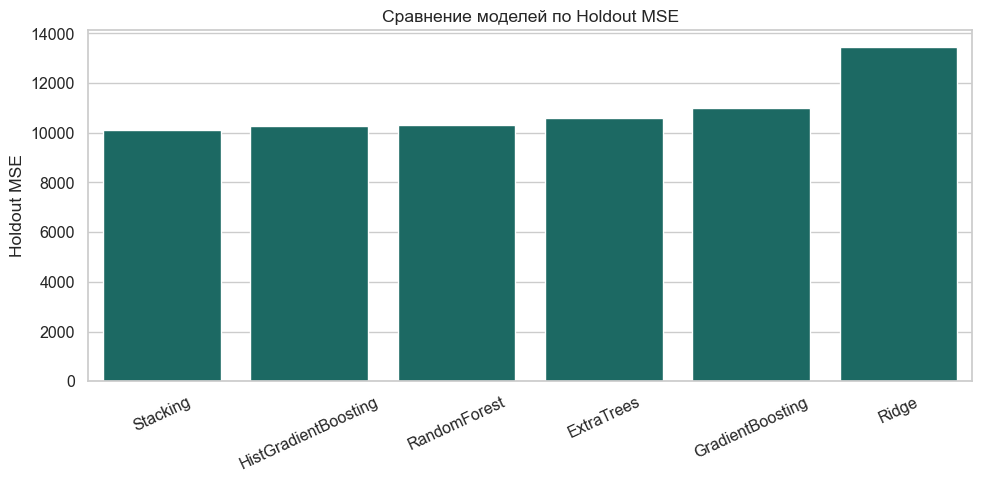

In [ ]:
all_results_df = pd.concat([
    base_summary_df[["model", "oof_mse", "holdout_mse"]],
    pd.DataFrame([{
        "model": "Stacking",
        "oof_mse": stack_oof_mse,
        "holdout_mse": stack_holdout_mse,
    }]),
], ignore_index=True).sort_values("holdout_mse")

display(all_results_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=all_results_df, x="model", y="holdout_mse", ax=ax, color="#0f766e")
ax.set_title("Сравнение моделей по Holdout MSE")
ax.set_xlabel("")
ax.set_ylabel("Holdout MSE")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 6. Оценка неопределенности

В работе рассчитаны три меры неопределенности. Эпистемическая неопределенность
            оценивается как разброс предсказаний базовых моделей: если модели дают сильно
            разные ответы, ансамбль менее уверен в предсказании. Алеаторная неопределенность
            оценивается отдельной моделью ожидаемой квадратичной ошибки, обученной на OOF-ошибках
            стекинга. Суммарная неопределенность равна сумме эпистемической и алеаторной.

Корреляции с фактической квадратичной ошибкой показывают, что наиболее полезной
            оказалась алеаторная неопределенность: Spearman-корреляция 0.586. Суммарная
            неопределенность тоже хорошо связана с ошибкой: Spearman 0.582. Эпистемическая
            неопределенность отдельно слабо коррелирует с ошибкой: Spearman 0.077.

Это означает, что в данной задаче ошибки чаще связаны не с сильным спором базовых
            моделей, а с шумностью или неоднозначностью самих объектов. Иными словами, даже
            когда модели согласны друг с другом, объект может быть сложным из-за свойств данных.

Калибровочная таблица подтверждает полезность uncertainty: средняя фактическая
            квадратичная ошибка растет от 3 570.656 в группе с очень низкой неопределенностью
            до 15 884.831 в группе с очень высокой неопределенностью. Медианная ошибка также
            растет монотонно: от 160.115 до 11 388.980. Значит суммарную неопределенность можно
            использовать как риск-скор: чем она выше, тем осторожнее стоит интерпретировать
            предсказание.

In [ ]:
# Эпистемическая неопределенность: разброс предсказаний разных базовых моделей.
epistemic_uncertainty = np.var(holdout_model_predictions, axis=1)

# Алеаторная неопределенность: модель ожидаемой квадратичной ошибки.
# Для ее обучения используем OOF-ошибки стекинга, чтобы цель residual_model
# была рассчитана вне обучения соответствующей строки.
oof_squared_error = (y_train - stack_oof_pred) ** 2

residual_model = build_pipeline(RandomForestRegressor(
    n_estimators=160,
    max_depth=12,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
))
residual_model.fit(X_train, oof_squared_error)

aleatoric_uncertainty = np.clip(residual_model.predict(X_holdout), 0, None)
total_uncertainty = aleatoric_uncertainty + epistemic_uncertainty
actual_squared_error = (y_holdout - stack_holdout_pred) ** 2

uncertainty_df = pd.DataFrame({
    "y_true": y_holdout,
    "stack_prediction": stack_holdout_pred,
    "actual_squared_error": actual_squared_error,
    "aleatoric_uncertainty": aleatoric_uncertainty,
    "epistemic_uncertainty": epistemic_uncertainty,
    "total_uncertainty": total_uncertainty,
})

display(uncertainty_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
y_true,7335.0,112.637764,131.593505,0.000000,0.000000,45.000000,223.500000,365.000000
stack_prediction,7335.0,113.434799,84.385840,0.000000,37.001736,102.744582,173.115720,356.243599
actual_squared_error,7335.0,10103.337303,16495.434337,0.000000,555.444708,3442.130262,12362.782748,126749.296064
aleatoric_uncertainty,7335.0,10195.762303,4928.560177,614.129051,6322.116161,10476.592150,13584.871669,40711.333672
epistemic_uncertainty,7335.0,564.021282,885.621389,1.414910,132.739976,295.103264,597.101125,15924.251206
total_uncertainty,7335.0,10759.783585,5028.643979,1102.921009,7103.379036,10949.090634,14080.551510,46799.108039


In [ ]:
corr_table = pd.DataFrame({
    "uncertainty": ["aleatoric", "epistemic", "total"],
    "spearman_corr_with_actual_squared_error": [
        uncertainty_df["aleatoric_uncertainty"].corr(uncertainty_df["actual_squared_error"], method="spearman"),
        uncertainty_df["epistemic_uncertainty"].corr(uncertainty_df["actual_squared_error"], method="spearman"),
        uncertainty_df["total_uncertainty"].corr(uncertainty_df["actual_squared_error"], method="spearman"),
    ],
    "pearson_corr_with_actual_squared_error": [
        uncertainty_df["aleatoric_uncertainty"].corr(uncertainty_df["actual_squared_error"]),
        uncertainty_df["epistemic_uncertainty"].corr(uncertainty_df["actual_squared_error"]),
        uncertainty_df["total_uncertainty"].corr(uncertainty_df["actual_squared_error"]),
    ],
})
display(corr_table)

,uncertainty,spearman_corr_with_actual_squared_error,pearson_corr_with_actual_squared_error
0,aleatoric,0.586486,0.277000
1,epistemic,0.077430,-0.015893
2,total,0.582377,0.268688


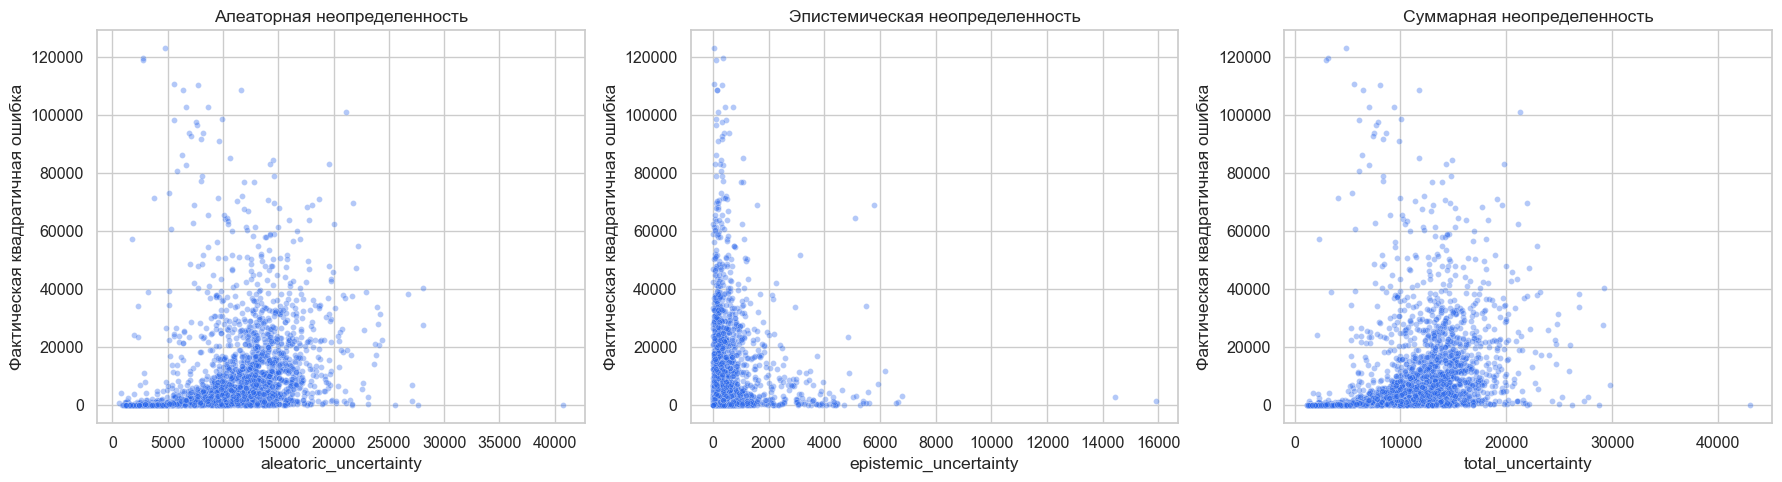

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ("aleatoric_uncertainty", "Алеаторная неопределенность"),
    ("epistemic_uncertainty", "Эпистемическая неопределенность"),
    ("total_uncertainty", "Суммарная неопределенность"),
]

for ax, (col, title) in zip(axes, pairs):
    sns.scatterplot(
        data=uncertainty_df.sample(min(2500, len(uncertainty_df)), random_state=RANDOM_STATE),
        x=col,
        y="actual_squared_error",
        alpha=0.35,
        s=18,
        ax=ax,
        color="#2563eb",
    )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Фактическая квадратичная ошибка")

plt.tight_layout()
plt.show()

,uncertainty_bin,mean_total_uncertainty,mean_actual_squared_error,median_actual_squared_error,count
0,очень низкая,3734.083173,3570.655797,160.115060,1467
1,низкая,8039.860042,7217.103115,1660.124397,1467
2,средняя,10958.487373,10732.936123,4947.657791,1467
3,высокая,13475.608782,13111.160393,8198.483580,1467
4,очень высокая,17590.878556,15884.831087,11388.980441,1467


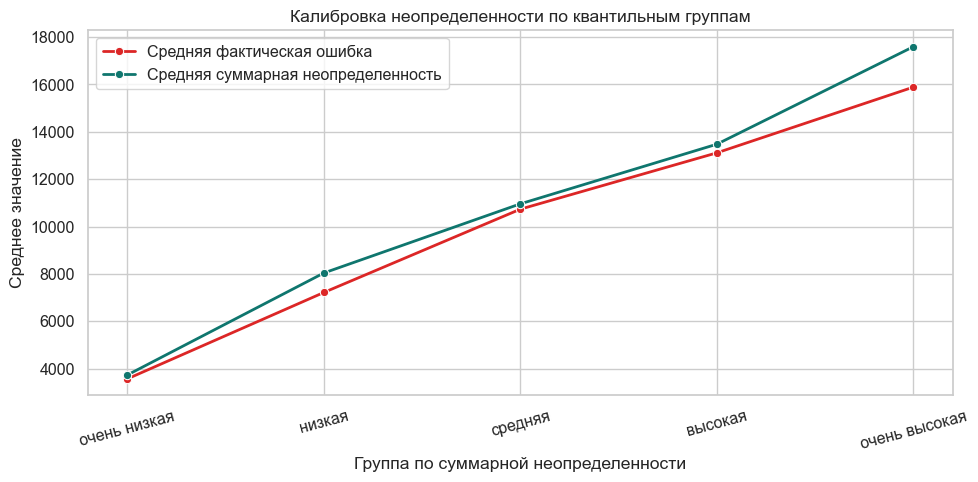

In [ ]:
calibration_df = uncertainty_df.copy()
calibration_df["uncertainty_bin"] = pd.qcut(
    calibration_df["total_uncertainty"].rank(method="first"),
    q=5,
    labels=["очень низкая", "низкая", "средняя", "высокая", "очень высокая"],
)

calibration_table = calibration_df.groupby("uncertainty_bin", observed=True).agg(
    mean_total_uncertainty=("total_uncertainty", "mean"),
    mean_actual_squared_error=("actual_squared_error", "mean"),
    median_actual_squared_error=("actual_squared_error", "median"),
    count=("actual_squared_error", "size"),
).reset_index()

display(calibration_table)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=calibration_table,
    x="uncertainty_bin",
    y="mean_actual_squared_error",
    marker="o",
    linewidth=2,
    label="Средняя фактическая ошибка",
    ax=ax,
    color="#dc2626",
)
sns.lineplot(
    data=calibration_table,
    x="uncertainty_bin",
    y="mean_total_uncertainty",
    marker="o",
    linewidth=2,
    label="Средняя суммарная неопределенность",
    ax=ax,
    color="#0f766e",
)
ax.set_title("Калибровка неопределенности по квантильным группам")
ax.set_xlabel("Группа по суммарной неопределенности")
ax.set_ylabel("Среднее значение")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
prediction_report = holdout_df[["_id", TARGET]].copy()
prediction_report = prediction_report.rename(columns={TARGET: "y_true"})
prediction_report["stack_prediction"] = stack_holdout_pred
prediction_report["actual_squared_error"] = actual_squared_error
prediction_report["aleatoric_uncertainty"] = aleatoric_uncertainty
prediction_report["epistemic_uncertainty"] = epistemic_uncertainty
prediction_report["total_uncertainty"] = total_uncertainty

prediction_report.to_csv("holdout_predictions.csv", index=False)
joblib.dump(
    {
        "base_fold_models": fitted_fold_models,
        "meta_model": meta_model,
        "residual_model": residual_model,
        "features": {
            "categorical": categorical_features,
            "numeric": numeric_features,
            "reference_date": str(reference_date),
        },
        "metrics": all_results_df,
    },
    "stacking_uncertainty_models.joblib",
)

display(prediction_report.head(10))
print("Сохранено: holdout_predictions.csv")
print("Сохранено: stacking_uncertainty_models.joblib")

,_id,y_true,stack_prediction,actual_squared_error,aleatoric_uncertainty,epistemic_uncertainty,total_uncertainty
0,17430718,211,184.982752,676.897203,12827.636629,189.931628,13017.568257
1,3640784,18,77.020921,3483.469081,14138.506254,132.028173,14270.534427
2,22866437,0,94.628887,8954.626177,15853.053982,235.947714,16089.001696
3,8178950,151,141.081965,98.367426,11940.366486,36.283998,11976.650484
4,39175915,0,31.269072,977.754844,11138.942869,579.267776,11718.210644
5,3073952,62,153.468255,8366.441619,11085.118809,151.300623,11236.419432
6,230930866,5,60.901669,3124.996549,8482.191737,64.839804,8547.031541
7,16323240,0,28.274427,799.443207,3721.758529,599.811396,4321.569925
8,389924,0,119.634203,14312.342543,15166.964254,133.706592,15300.670845
9,50770601,306,200.398181,11151.744176,16144.584121,973.686843,17118.270965


Сохранено: holdout_predictions.csv
Сохранено: stacking_uncertainty_models.joblib


## 7. Итоговые выводы

В ноутбуке реализован полный цикл ансамблевого решения задачи регрессии:
            подготовка признаков, стратифицированная кросс-валидация через бины целевой
            переменной, обучение пяти базовых моделей, получение OOF-предсказаний, обучение
            мета-модели и оценка неопределенности.

Главный результат по качеству: стекинг занял первое место среди всех рассмотренных
            моделей с holdout MSE 10 103.337. Лучшая одиночная модель, `HistGradientBoosting`,
            получила holdout MSE 10 270.408. Значит объединение моделей через мета-модель
            дало улучшение, пусть и не радикальное.

Главный результат по неопределенности: суммарная неопределенность имеет Spearman-
            корреляцию 0.582 с фактической квадратичной ошибкой. Кроме того, при разбиении
            объектов на группы по uncertainty фактическая ошибка монотонно растет. Это означает,
            что рассчитанная неопределенность не является случайной технической величиной:
            она действительно помогает находить объекты, где модель с большей вероятностью
            ошибется.

Практический вывод: для финального прогноза стоит использовать стекинг, а вместе
            с самим предсказанием хранить `total_uncertainty`. Низкая неопределенность означает
            более надежный прогноз, высокая — повод проверять объект вручную или относиться
            к предсказанию осторожнее.

In [ ]:
best_single = base_summary_df.iloc[0]
stack_rank = int(all_results_df.reset_index(drop=True).index[all_results_df["model"].eq("Stacking")][0] + 1)
total_spearman = corr_table.loc[
    corr_table["uncertainty"].eq("total"),
    "spearman_corr_with_actual_squared_error",
].iloc[0]

print("Ключевые результаты:")
print(f"- Лучшая одиночная модель: {best_single['model']} с Holdout MSE = {best_single['holdout_mse']:.3f}")
print(f"- Стекинг: Holdout MSE = {stack_holdout_mse:.3f}, место среди всех моделей по holdout = {stack_rank}")
print(f"- Spearman-корреляция суммарной неопределенности с фактической ошибкой = {total_spearman:.3f}")
print("- Чем выше эта корреляция и чем монотоннее калибровочная таблица, тем полезнее uncertainty для поиска рискованных предсказаний.")

Ключевые результаты:
- Лучшая одиночная модель: HistGradientBoosting с Holdout MSE = 10270.408
- Стекинг: Holdout MSE = 10103.337, место среди всех моделей по holdout = 1
- Spearman-корреляция суммарной неопределенности с фактической ошибкой = 0.582
- Чем выше эта корреляция и чем монотоннее калибровочная таблица, тем полезнее uncertainty для поиска рискованных предсказаний.
